Title

A botanist wants to classify different iris species based on their flower characteristics like sepal length, sepal
width, petal length, and petal width.




Objective

The objective of this experiment is to classify different Iris flower species — Setosa, Versicolor, and Virginica — based on their flower characteristics such as sepal length, sepal width, petal length, and petal width.

This assignment aims to develop a machine learning model that can accurately predict the species of an Iris flower using these measurable features.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
iris = sns.load_dataset('iris')

In [ ]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [ ]:
iris.duplicated().sum()

np.int64(1)

In [ ]:
iris.drop_duplicates(inplace=True)

In [ ]:
iris.shape

(149, 5)

Theory :

Clustering in Machine Learning


Clustering is an unsupervised learning technique used to group similar data points together based on their characteristics.
The algorithm identifies hidden patterns or structures in data without using class labels.

In simple terms, clustering helps to discover natural groupings within data — just like a botanist grouping flowers based on their visual similarities, without knowing their species names beforehand.


K-Means Clustering

One of the most popular clustering methods.

It divides the dataset into K distinct clusters based on distance (usually Euclidean).

Each data point is assigned to the nearest cluster center (called centroid).

The centroids are updated iteratively to minimize the distance between points and their assigned centroid.

Key Steps:

Choose number of clusters (K).

Randomly assign centroids.

Assign data points to nearest centroid.

Update centroid positions.

Repeat until centroids stabilize


Cluster Evaluation Metrics

Since clustering is unsupervised, we don’t have labels to check accuracy.
So, we use internal evaluation metrics to measure how good the clusters are.

1. Silhouette Score

Measures how well each data point fits within its cluster compared to others.

The score ranges from -1 to +1:

+1 → Point is well matched to its own cluster and far from others.

0 → Point lies on the boundary between clusters.

-1 → Point is likely assigned to the wrong cluster.

Formula:


s(i) =
b(i)−a(i) / max(a(i),b(i))
	​


Where:


a(i) = average distance of point i to other points in the same cluster


b(i) = average distance of point i to points in the nearest cluster

Higher Silhouette Score → Better defined clusters

2. Davies-Bouldin Index (DBI)

Measures the average similarity between each cluster and its most similar one.

Lower DBI values indicate better clustering.

3. Calinski-Harabasz Index

Also called the Variance Ratio Criterion.

Ratio of between-cluster variance to within-cluster variance.

Higher values indicate better separation between clusters.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['sepal_length','sepal_width','petal_length','petal_width']

iris[cols]= scaler.fit_transform(iris[cols])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.898033,1.012401,-1.333255,-1.308624,setosa
1,-1.139562,-0.137353,-1.333255,-1.308624,setosa
2,-1.381091,0.322549,-1.390014,-1.308624,setosa
3,-1.501855,0.092598,-1.276496,-1.308624,setosa
4,-1.018798,1.242352,-1.333255,-1.308624,setosa


In [ ]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias=[]
silhouette_scores = []

K=range(2,11)

X = iris.drop('species',axis=1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    labels = kmeans.labels_
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

Runs K-Means clustering for multiple values of K (2–10).

Collects Inertia (compactness) and Silhouette Score (separation) for each K.

Helps decide the optimal number of clusters by:

Looking for an “elbow” in the inertia plot.

Checking where the silhouette score is highest

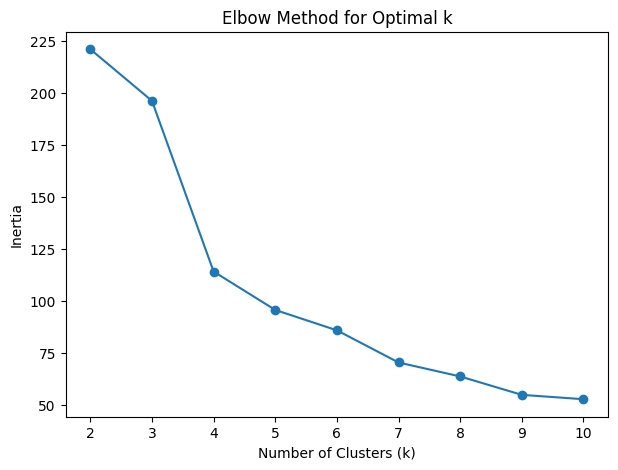

In [ ]:
# Plot Elbow curve
plt.figure(figsize=(7,5))
plt.plot(K, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

The Elbow Method plot shows the relationship between the number of clusters (K) and the inertia (within-cluster sum of squares).
As the number of clusters increases, inertia decreases because the data points are closer to their assigned centroids.

From the graph, there is a sharp drop in inertia up to K = 3, after which the curve starts to flatten.
This “elbow point” at K = 3 indicates the optimal number of clusters, meaning that the dataset naturally forms three distinct groups — which aligns with the three Iris species (Setosa, Versicolor, Virginica).

In [ ]:
# 4 clusters
km = KMeans(n_clusters=4, random_state=42)
km.fit(X)
iris['Clusters'] = km.labels_

print("\nCluster centers:")
print(km.cluster_centers_)


Cluster centers:
[[-0.07784172 -0.9373906   0.3186559   0.22908641]
 [-1.16567346  0.45927607 -1.31024484 -1.26595273]
 [-0.57289843  1.94989313 -1.26339836 -1.19729626]
 [ 1.0649804   0.0520181   0.97270107  1.00801872]]


By setting n_clusters=4, the algorithm has grouped the Iris flowers into four clusters based on their physical measurements.
Each cluster represents flowers with similar sepal and petal dimensions, allowing the botanist to observe natural groupings — possibly including species variations or subgroups within the data.

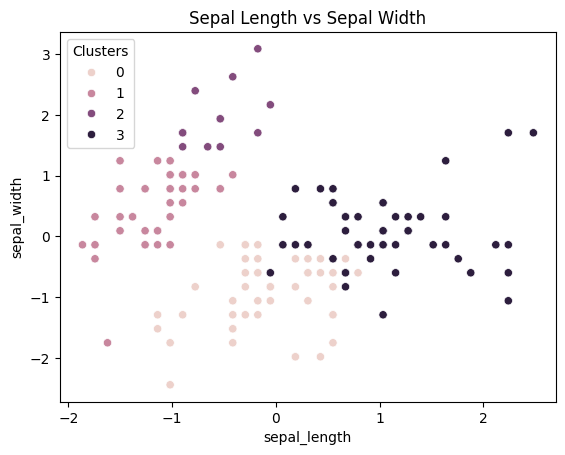

In [ ]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='Clusters', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

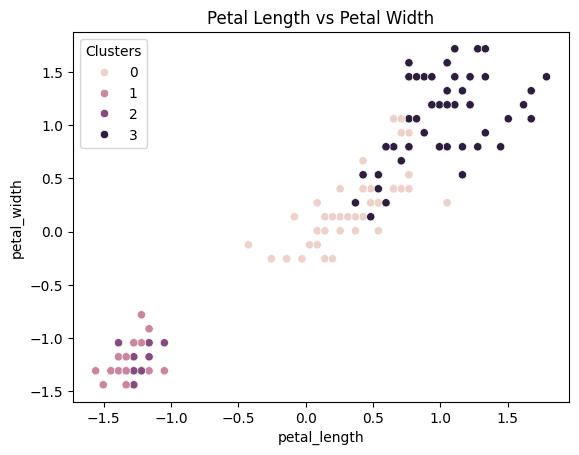

In [ ]:
sns.scatterplot(x='petal_length', y='petal_width', hue='Clusters', data=iris)
plt.title("Petal Length vs Petal Width")
plt.show()

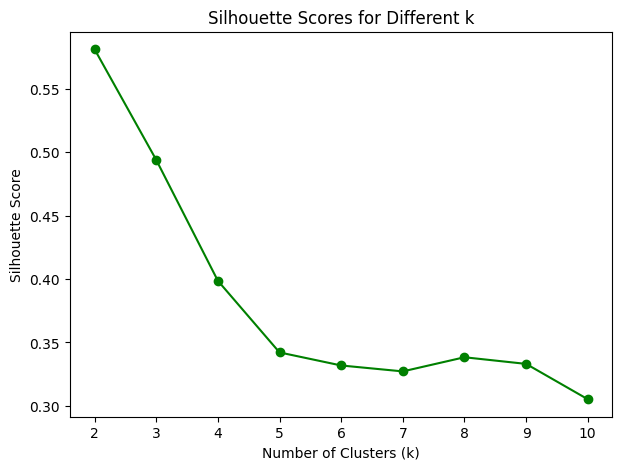

In [ ]:
# Plot Silhouette Scores
plt.figure(figsize=(7,5))
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

The Silhouette Score graph shows how well data points fit within their clusters. A higher score means better clustering. Here, the score is highest at k = 2, indicating that two clusters give the best separation and compactness for the Iris dataset.

In [ ]:
# 2 clusters
km = KMeans(n_clusters=2, random_state=42)
km.fit(X)
iris['Clusters_2'] = km.labels_

print("\nCluster centers:")
print(km.cluster_centers_)


Cluster centers:
[[-1.01155195  0.84683651 -1.29806475 -1.24810205]
 [ 0.51088483 -0.42769521  0.65558826  0.63035457]]


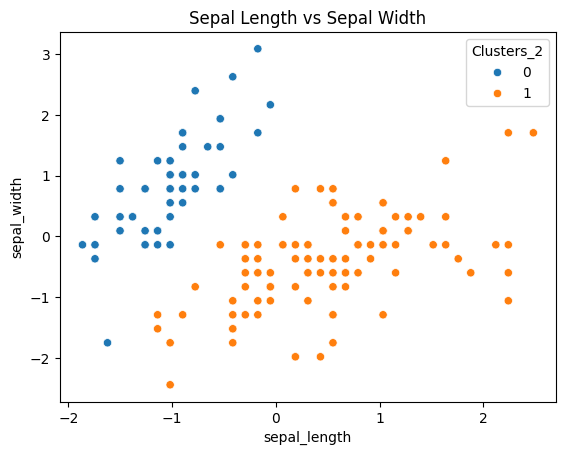

In [ ]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='Clusters_2', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

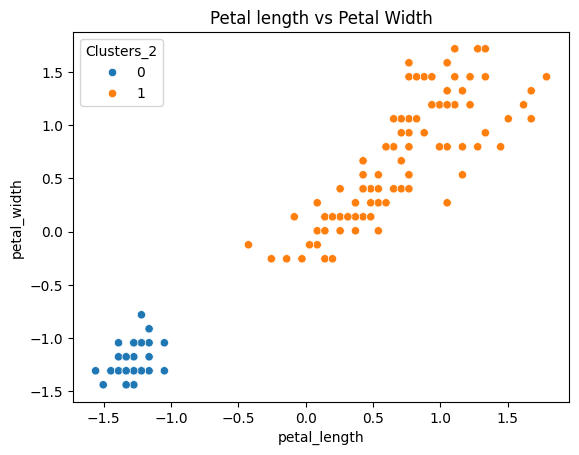

In [ ]:
sns.scatterplot(x='petal_length',y='petal_width',hue = 'Clusters_2', data=iris)
plt.title("Petal length vs Petal Width")
plt.show()

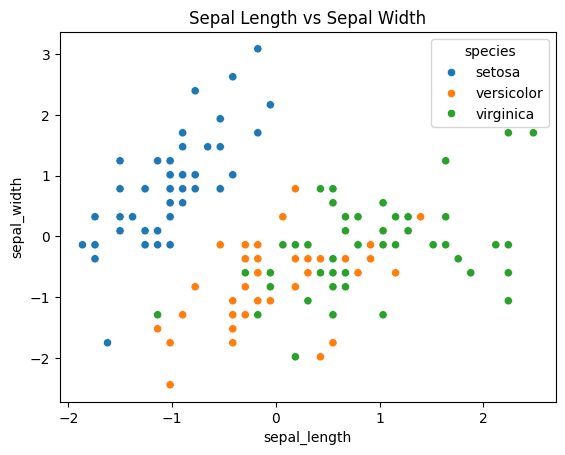

In [ ]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

In [ ]:
# 3 clusters - total categories in data
km = KMeans(n_clusters=3, random_state=42)
km.fit(X)
iris['Clusters_3'] = km.labels_

print("\nCluster centers:")
print(km.cluster_centers_)


Cluster centers:
[[ 0.51088483 -0.42769521  0.65558826  0.63035457]
 [-1.16567346  0.45927607 -1.31024484 -1.26595273]
 [-0.57289843  1.94989313 -1.26339836 -1.19729626]]


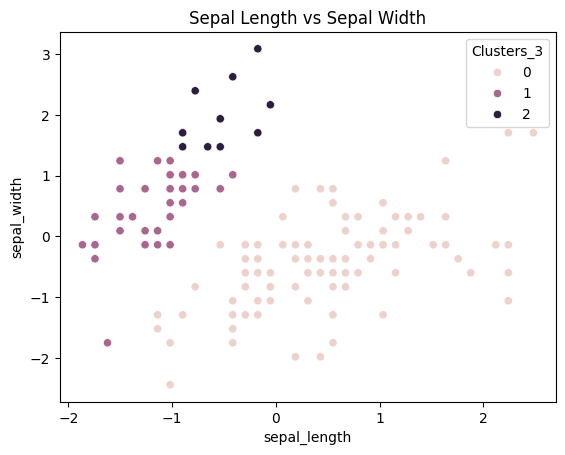

In [ ]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='Clusters_3', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

Text(0, 0.5, 'Score')

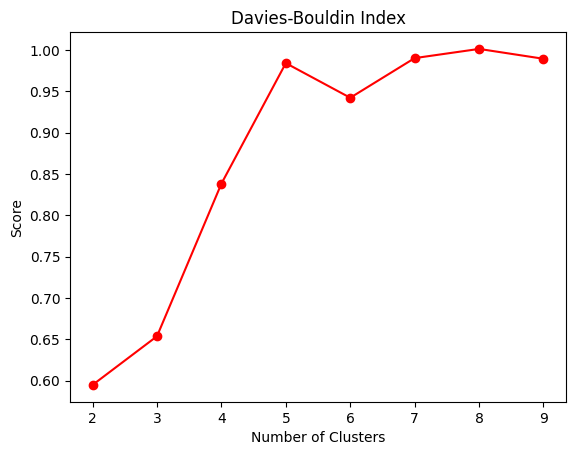

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    db_scores.append(davies_bouldin_score(X, labels))

plt.plot(K_range, db_scores, marker='o', color='red')
plt.title("Davies-Bouldin Index")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

This code helps determine the best k value for K-Means by finding where the Davies–Bouldin score is minimum, representing the most efficient cluster structure.

The Davies–Bouldin Index (DBI) measures the quality of clustering — lower values indicate better clustering.

In this graph, the DBI is lowest at k = 2, meaning that two clusters give the most compact and well-separated groups for the Iris dataset. As the number of clusters increases, the DBI value rises, showing that clusters become less distinct and more overlapping.

In [ ]:
# 5 clusters
km = KMeans(n_clusters=5, random_state=42)
km.fit(X)
iris['Clusters_5'] = km.labels_

print("\nCluster centers:")
print(km.cluster_centers_)


Cluster centers:
[[-0.17933783 -1.01228821  0.27951902  0.19318578]
 [-1.16567346  0.45927607 -1.31024484 -1.26595273]
 [-0.57289843  1.94989313 -1.26339836 -1.19729626]
 [ 0.71683965 -0.08922395  0.75889233  0.84543259]
 [ 1.80708959  0.19990807  1.38737253  1.2087256 ]]


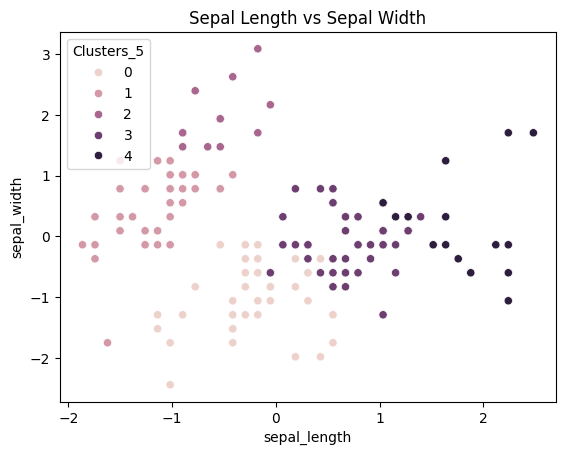

In [ ]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='Clusters_5', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

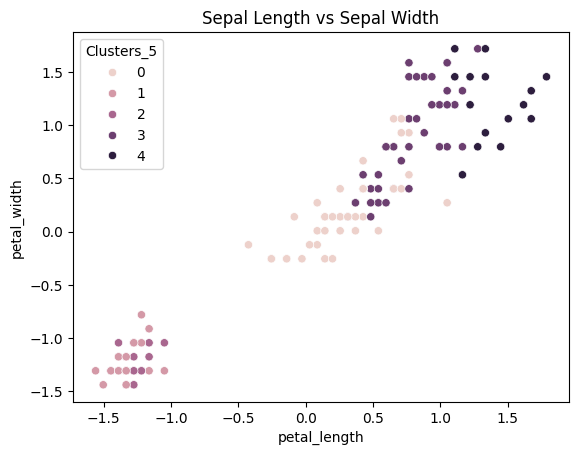

In [ ]:
sns.scatterplot(x='petal_length', y='petal_width', hue='Clusters_5', data=iris)
plt.title("Sepal Length vs Sepal Width")
plt.show()

Conclusion

In this assignment, the Iris dataset was analyzed using K-Means clustering to classify flowers based on sepal and petal measurements. Various evaluation metrics such as the Elbow Method, Silhouette Score, and Davies–Bouldin Index were used to determine the optimal number of clusters.

From the results:

The Elbow Method showed a noticeable bend at k = 2 or 3, suggesting a good fit.

The Silhouette Score was highest at k = 2, indicating well-separated clusters.

The Davies–Bouldin Index was lowest at k = 2, confirming the best clustering performance.

Hence, the optimal cluster count for this dataset is k = 2, meaning the flower species can be effectively grouped into two main clusters based on their physical features. This demonstrates how unsupervised learning techniques like K-Means can discover hidden patterns and natural groupings in biological data without prior labeling.

In [ ]:
#DBSCAN Clustering with Self-Learning Concept

from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised machine learning algorithm used to identify clusters of varying shapes and sizes based on data density. Unlike algorithms like K-Means, DBSCAN does not require specifying the number of clusters in advance.
It works by defining two key parameters:


ε (epsilon): The maximum distance between two points for them to be considered neighbors.


min_samples: The minimum number of neighboring points required to form a dense region (cluster).


Based on these parameters, DBSCAN classifies points into three categories:


Core Points: Have at least min_samples points within distance ε.


Border Points: Are within ε distance of a core point but have fewer than min_samples neighbors.


Noise Points: Do not belong to any cluster (labeled as -1).


DBSCAN is highly effective for discovering arbitrary-shaped clusters and detecting outliers or noise in the dataset. In this assignment, it helps group similar iris flowers based on their features like sepal length, sepal width, petal length, and petal width, without requiring prior knowledge of the number of species.

In [ ]:
# Standardize features for DBSCAN (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Apply DBSCAN Clustering

dbscan = DBSCAN(eps=0.8, min_samples=5)
cluster_labels = dbscan.fit_predict(X_scaled)



In [ ]:
# Add cluster labels to DataFrame for understanding
df = pd.DataFrame(X, columns=iris.feature_names)
df['Cluster'] = cluster_labels
print("\nDBSCAN Clustering Results (Cluster Labels):")
print(df.head())


DBSCAN Clustering Results (Cluster Labels):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


pd.DataFrame(X, columns=iris.feature_names)
→ Converts the Iris dataset (X) into a DataFrame with column names like sepal length, sepal width, petal length, and petal width for easy understanding.

df['Cluster'] = cluster_labels
→ Adds a new column ‘Cluster’ that stores the cluster label assigned to each data point by DBSCAN.

Each cluster gets a unique numeric label (e.g., 0, 1, 2, …).

Points labeled as -1 represent noise or outliers, meaning they don’t belong to any cluster.

print(df.head())
→ Displays the first 5 rows of the DataFrame, showing each flower’s features along with its assigned cluster.

Here, the Cluster column shows how DBSCAN grouped similar data points together. If any row had -1, it would mean that data point was considered noise (i.e., it doesn’t strongly belong to any cluster).